# **FINAL PROJECT**

In [3]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn import svm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv('/kaggle/input/college-basketball-dataset/cbb.csv')
df.head()

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Wisconsin,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015
2,Michigan,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018
3,Texas Tech,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019
4,Gonzaga,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017


In [67]:
df.describe
df['POSTSEASON'].value_counts()

POSTSEASON
64.0    320
32.0    160
16.0     80
8.0      40
68.0     40
4.0      20
2.0      10
1.0      10
Name: count, dtype: int64

# **1.1 Correlation of all numerical data**

In [5]:
cols = df.columns
cols

Index(['TEAM', 'CONF', 'G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D',
       'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O',
       '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'YEAR'],
      dtype='object')

In [6]:
postseason_mapping = {'Champions':1,
                     '2ND':2,
                     'F4':4,
                     'E8':8,
                     'S16':16,
                     'R32':32,
                     'R64':64,
                     'R68':68}
df['POSTSEASON'] = df['POSTSEASON'].map(postseason_mapping)


In [7]:
num_cols = df._get_numeric_data().columns
num_cols


Index(['G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD',
       'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T',
       'WAB', 'POSTSEASON', 'SEED', 'YEAR'],
      dtype='object')

In [8]:
numeric_df = df._get_numeric_data()

In [9]:
corr = numeric_df.corr()
corr

,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
G,1.000000,0.608824,0.458818,-0.358563,0.470220,0.223691,-0.313113,-0.235440,0.009625,0.271317,...,-0.051500,0.180954,-0.323567,0.200767,-0.162106,-0.074646,0.366441,-4.109484e-01,-0.363497,-2.441365e-01
W,0.608824,1.000000,0.736713,-0.655700,0.794127,0.590957,-0.585786,-0.439382,0.135311,0.309950,...,-0.255937,0.551565,-0.521364,0.418986,-0.444215,-0.025344,0.859995,-5.126279e-01,-0.540782,4.552541e-03
ADJOE,0.458818,0.736713,1.000000,-0.494039,0.863203,0.723180,-0.306172,-0.597191,-0.121562,0.253776,...,-0.307819,0.638174,-0.296911,0.559109,-0.193225,0.056921,0.821904,-5.266968e-01,-0.744609,1.846384e-02
ADJDE,-0.358563,-0.655700,-0.494039,1.000000,-0.841425,-0.195558,0.785367,0.172985,-0.269400,-0.291944,...,0.176116,-0.234620,0.711324,-0.068731,0.573964,0.195574,-0.799711,4.626590e-01,0.690730,2.090318e-02
BARTHAG,0.470220,0.794127,0.863203,-0.841425,1.000000,0.532123,-0.611977,-0.447057,0.066780,0.304284,...,-0.286142,0.504225,-0.564498,0.365767,-0.431831,-0.073865,0.930164,-5.322559e-01,-0.827418,-4.069689e-04
EFG_O,0.223691,0.590957,0.723180,-0.195558,0.532123,1.000000,-0.104251,-0.371265,-0.158853,-0.145350,...,-0.366404,0.892808,-0.086651,0.749952,-0.094635,0.108285,0.540421,-2.122728e-01,-0.231130,1.407767e-01
EFG_D,-0.313113,-0.585786,-0.306172,0.785367,-0.611977,-0.104251,1.000000,0.051693,-0.058905,-0.363482,...,0.067946,-0.128741,0.905281,-0.038543,0.720319,0.234568,-0.614681,2.490299e-01,0.367349,1.492915e-01
TOR,-0.235440,-0.439382,-0.597191,0.172985,-0.447057,-0.371265,0.051693,1.000000,0.149789,0.172764,...,0.284840,-0.307227,0.044391,-0.310053,0.043810,-0.067096,-0.436574,2.036838e-01,0.266311,-1.180771e-01
TORD,0.009625,0.135311,-0.121562,-0.269400,0.066780,-0.158853,-0.058905,0.149789,1.000000,0.161732,...,0.358317,-0.099908,-0.018906,-0.175285,-0.108381,-0.031180,0.111490,-4.783297e-02,-0.002099,-1.091052e-01
ORB,0.271317,0.309950,0.253776,-0.291944,0.304284,-0.145350,-0.363482,0.172764,0.161732,1.000000,...,0.206197,-0.108346,-0.372845,-0.118274,-0.187496,-0.080415,0.306895,-1.875822e-01,-0.293490,-2.913323e-01


**sorting the correlation in terms of seed (negative correlation means a lower seed, such as seed 2, indicating a stronger team)**

In [10]:
seed = [col for col in corr.columns if 'SEED' in col]

if seed:
    seed_corr = corr[seed[0]].sort_values(ascending=False)
    print(seed_corr)
else:
    print("seed column not found.")

SEED          1.000000
ADJDE         0.690730
POSTSEASON    0.599058
2P_D          0.369974
EFG_D         0.367349
TOR           0.266311
FTRD          0.214671
3P_D          0.159121
DRB           0.092929
FTR           0.083382
ADJ_T         0.013694
YEAR         -0.001454
TORD         -0.002099
3P_O         -0.152047
2P_O         -0.219235
EFG_O        -0.231130
ORB          -0.293490
G            -0.363497
W            -0.540782
ADJOE        -0.744609
BARTHAG      -0.827418
WAB          -0.913801
Name: SEED, dtype: float64


**each numerical value over time**

In [11]:
time_corr = corr['YEAR']
time_corr

G            -2.441365e-01
W             4.552541e-03
ADJOE         1.846384e-02
ADJDE         2.090318e-02
BARTHAG      -4.069689e-04
EFG_O         1.407767e-01
EFG_D         1.492915e-01
TOR          -1.180771e-01
TORD         -1.091052e-01
ORB          -2.913323e-01
DRB          -3.801982e-01
FTR          -4.773998e-01
FTRD         -4.141800e-01
2P_O          2.310886e-01
2P_D          2.348774e-01
3P_O         -5.988247e-02
3P_D         -7.783459e-02
ADJ_T         1.510145e-01
WAB           3.037469e-02
POSTSEASON   -3.196480e-14
SEED         -1.453555e-03
YEAR          1.000000e+00
Name: YEAR, dtype: float64

# **1.2 Median values of all numerical data**

In [12]:
median_values = numeric_df.median(numeric_only=True)
median_values

G               31.0000
W               16.0000
ADJOE          102.8000
ADJDE          103.2000
BARTHAG          0.4756
EFG_O           49.8000
EFG_D           50.1000
TOR             18.6000
TORD            18.5000
ORB             29.4000
DRB             29.5000
FTR             34.3000
FTRD            34.1000
2P_O            49.0000
2P_D            49.3000
3P_O            34.1000
3P_D            34.3000
ADJ_T           67.7000
WAB             -7.9000
POSTSEASON      64.0000
SEED             9.0000
YEAR          2018.0000
dtype: float64

# **1.3 Mean values of all numerical data**

In [13]:
mean_values = numeric_df.mean(numeric_only=True)
mean_values

G               30.486233
W               15.990633
ADJOE          103.151320
ADJDE          103.153250
BARTHAG          0.494067
EFG_O           49.887823
EFG_D           50.087113
TOR             18.696509
TORD            18.625092
ORB             29.308544
DRB             29.516747
FTR             34.529066
FTRD            34.802555
2P_O            49.112433
2P_D            49.289299
3P_O            34.185580
3P_D            34.369316
ADJ_T           67.735339
WAB             -7.579620
POSTSEASON      44.161765
SEED             8.801471
YEAR          2017.828555
dtype: float64

# **1.4 Standard deviation values of all numerical data**

In [14]:
standard_div = numeric_df.std(numeric_only=True)
standard_div

G              3.951584
W              6.572893
ADJOE          7.264859
ADJDE          6.511989
BARTHAG        0.255338
EFG_O          3.078505
EFG_D          2.894967
TOR            2.104119
TORD           2.241067
ORB            4.214131
DRB            3.234810
FTR            5.514264
FTRD           6.396757
2P_O           3.400389
2P_D           3.317012
3P_O           2.729186
3P_D           2.435546
ADJ_T          3.091703
WAB            6.815976
POSTSEASON    22.921786
SEED           4.673461
YEAR           3.257824
dtype: float64

# **1.5 Grouping postseason statistics**

In [15]:
postseason_Wins = df.groupby('POSTSEASON')[['W']].describe()
postseason_Wins

W                                                     
            count       mean       std   min    25%   50%    75%   max
POSTSEASON                                                            
1.0          10.0  32.800000  4.104198  22.0  32.25  34.5  35.00  36.0
2.0          10.0  31.600000  3.339993  26.0  29.25  31.5  33.00  37.0
4.0          20.0  29.700000  4.736199  17.0  28.50  30.0  32.00  38.0
8.0          40.0  27.750000  4.030334  17.0  25.75  28.5  31.00  34.0
16.0         80.0  25.987500  3.985714  16.0  23.75  26.5  29.00  33.0
32.0        160.0  24.568750  3.845477  14.0  22.00  24.5  27.00  34.0
64.0        320.0  22.571875  3.547416  12.0  20.00  23.0  25.00  31.0
68.0         40.0  19.600000  3.287895  12.0  18.00  20.0  21.25  28.0

In [16]:
postseason_ADJ = df.groupby('POSTSEASON')[['ADJOE', 'ADJDE']].describe()
postseason_ADJ

ADJOE                                                         \
            count        mean       std    min      25%     50%      75%   
POSTSEASON                                                                 
1.0          10.0  121.360000  4.525287  112.5  120.100  122.25  123.175   
2.0          10.0  118.910000  5.737876  110.8  114.600  117.50  122.850   
4.0          20.0  116.755000  4.436508  108.7  112.825  117.50  120.375   
8.0          40.0  116.272500  5.250738   99.4  113.000  116.55  119.675   
16.0         80.0  114.967500  4.681982  101.7  111.700  114.90  118.025   
32.0        160.0  112.619375  4.568879  101.8  109.775  112.55  115.425   
64.0        320.0  108.718437  5.629852   90.6  104.900  108.75  112.400   
68.0         40.0  105.927500  6.905182   95.0  100.175  105.95  109.525   

                   ADJDE                                                       \
              max  count        mean       std   min     25%     50%      75%   
POSTSEASON                                                                      
1.0         128.4   10.0   90.980000  2.707110  84.5  90.675   91.25   91.450   
2.0         129.1   10.0   91.310000  3.672253  85.2  89.575   91.95   93.675   
4.0         122.7   20.0   93.075000  3.966289  84.0  90.975   93.70   95.825   
8.0         125.3   40.0   93.037500  4.096821  85.7  90.275   92.45   95.525   
16.0        123.3   80.0   93.720000  4.143392  85.4  90.650   93.80   96.525   
32.0        125.2  160.0   95.108125  4.035097  84.1  92.500   94.80   97.150   
64.0        126.8  320.0   98.295000  4.982569  84.3  95.000   98.00  101.800   
68.0        122.4   40.0  102.060000  6.035357  91.0  97.975  100.90  105.825   

                   
              max  
POSTSEASON         
1.0          94.5  
2.0          96.2  
4.0         100.9  
8.0         103.3  
16.0        107.1  
32.0        114.7  
64.0        114.5  
68.0        115.6

In [17]:
Postseason_WAB = df.groupby('POSTSEASON')[['WAB']].describe()
Postseason_WAB

WAB                                                     
            count      mean       std   min    25%   50%     75%   max
POSTSEASON                                                            
1.0          10.0  8.540000  2.364647   4.7  7.050  8.95  10.550  11.1
2.0          10.0  7.010000  2.186550   3.9  5.825  6.95   8.300  11.3
4.0          20.0  5.665000  3.647245  -0.3  2.800  5.55   7.925  13.1
8.0          40.0  5.652500  3.529436  -5.6  3.975  6.50   7.725  11.6
16.0         80.0  4.382500  3.195161  -5.1  2.500  4.55   6.725  10.2
32.0        160.0  2.888125  3.410018 -12.2  1.075  2.60   4.525  11.3
64.0        320.0 -0.586563  4.165612 -14.5 -3.300  0.30   2.125  11.3
68.0         40.0 -4.305000  5.293390 -15.6 -8.225 -3.00   0.625   1.9

In [18]:
Postseason_EFG = df.groupby('POSTSEASON')[[ 'EFG_O', 'EFG_D']].describe()
Postseason_EFG

EFG_O                                                          \
            count       mean       std   min     25%    50%     75%   max   
POSTSEASON                                                                  
1.0          10.0  54.640000  2.870617  50.6  52.225  54.55  56.475  59.5   
2.0          10.0  53.770000  3.392819  49.3  51.775  53.70  54.750  61.0   
4.0          20.0  53.005000  2.742161  47.3  51.450  53.25  54.600  57.7   
8.0          40.0  53.260000  2.686891  47.5  51.975  53.25  54.825  59.0   
16.0         80.0  52.707500  2.753997  46.1  51.050  52.15  54.625  59.8   
32.0        160.0  52.079375  2.414633  46.6  50.600  52.00  53.725  58.9   
64.0        320.0  51.789062  2.682354  44.7  49.700  51.60  53.700  59.2   
68.0         40.0  50.657500  2.141637  46.1  49.300  50.90  51.950  54.4   

            EFG_D                                                          
            count       mean       std   min     25%    50%     75%   max  
POSTSEASON                                                                 
1.0          10.0  46.320000  1.753599  44.4  44.725  46.15  47.750  49.1  
2.0          10.0  46.420000  2.465225  41.1  46.125  47.60  47.925  48.6  
4.0          20.0  46.440000  2.954105  39.6  45.200  46.75  47.325  51.7  
8.0          40.0  46.960000  2.418709  42.3  45.100  46.85  48.500  52.5  
16.0         80.0  47.142500  2.443062  41.3  45.775  47.20  48.825  52.7  
32.0        160.0  47.493750  2.074969  42.3  45.900  47.70  48.825  54.7  
64.0        320.0  48.175313  2.293206  41.9  46.700  48.15  49.700  55.7  
68.0         40.0  49.000000  2.274496  43.1  47.750  49.25  50.450  53.5

In [19]:
postseason_BARTHAG = df.groupby('POSTSEASON')[[ 'BARTHAG']].describe()
postseason_BARTHAG

BARTHAG                                                           \
             count      mean       std     min       25%      50%       75%   
POSTSEASON                                                                    
1.0           10.0  0.962280  0.017515  0.9171  0.958875  0.96730  0.973325   
2.0           10.0  0.947810  0.027539  0.9062  0.924750  0.95265  0.972000   
4.0           20.0  0.922440  0.040327  0.8350  0.899800  0.93365  0.946400   
8.0           40.0  0.914007  0.063879  0.6786  0.897125  0.93450  0.957000   
16.0          80.0  0.901175  0.066892  0.4981  0.882200  0.91675  0.936800   
32.0         160.0  0.859177  0.087839  0.2909  0.833900  0.87510  0.915250   
64.0         320.0  0.730332  0.166190  0.2398  0.608975  0.79440  0.862900   
68.0          40.0  0.580653  0.247499  0.1522  0.345725  0.61525  0.803525   

                    
               max  
POSTSEASON          
1.0         0.9764  
2.0         0.9791  
4.0         0.9842  
8.0         0.9744  
16.0        0.9710  
32.0        0.9663  
64.0        0.9612  
68.0        0.9148

In [20]:
postseason_SEED = df.groupby('POSTSEASON')[['SEED']].describe()
postseason_SEED

SEED                                                    
            count      mean       std   min    25%   50%    75%   max
POSTSEASON                                                           
1.0          10.0   2.00000  2.000000   1.0   1.00   1.0   1.75   7.0
2.0          10.0   3.50000  2.758824   1.0   1.00   3.0   4.75   8.0
4.0          20.0   4.80000  3.577709   1.0   2.00   3.5   7.50  11.0
8.0          40.0   4.15000  3.570176   1.0   2.00   3.0   5.25  15.0
16.0         80.0   5.42500  3.644920   1.0   3.00   4.0   7.00  15.0
32.0        160.0   7.42500  3.779371   1.0   4.75   7.0  10.00  16.0
64.0        320.0  10.94375  3.917242   1.0   8.00  12.0  14.00  16.0
68.0         40.0  13.60000  2.457850  11.0  11.00  14.5  16.00  16.0

# Adding non-numerical data

# VISUALIZATIONS

<Axes: >

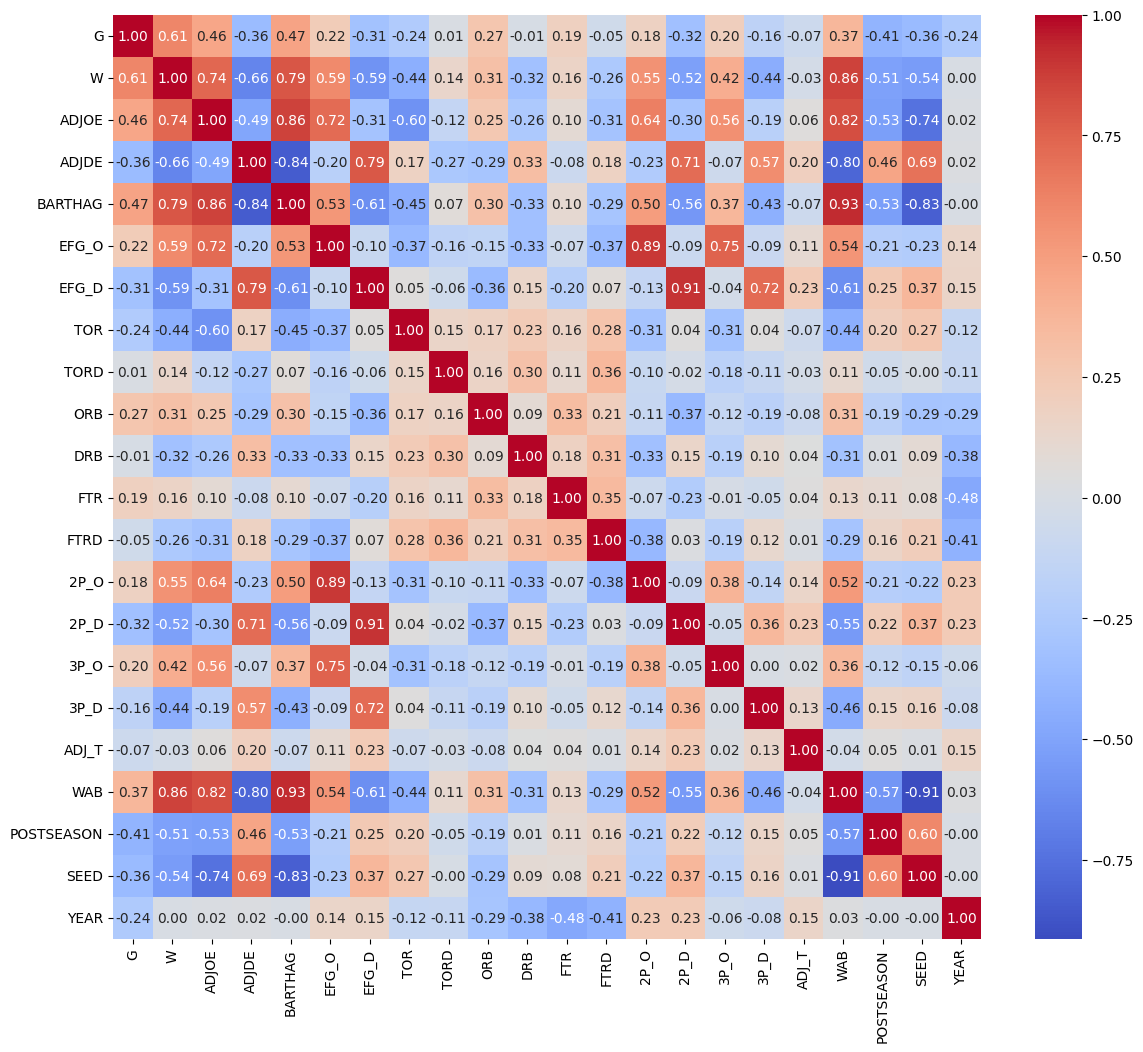

In [21]:
plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
#sns.heatmap(corr,cmap='coolwarm', fmt='.3f')

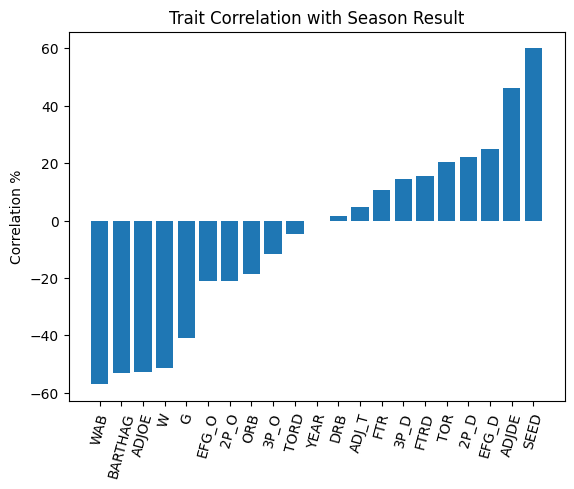

In [22]:
postseason_corr = corr['POSTSEASON'].sort_values()
postseason_corr = postseason_corr[:-1]
plt.bar(postseason_corr.index,postseason_corr *100)
plt.xticks(rotation=75)
plt.ylabel('Correlation %')
plt.title('Trait Correlation with Season Result')
plt.show()


In [23]:
postseason_BARTHAG.index

Index([1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 68.0], dtype='float64', name='POSTSEASON')

Text(0.5, 0, 'Postseason Placement')

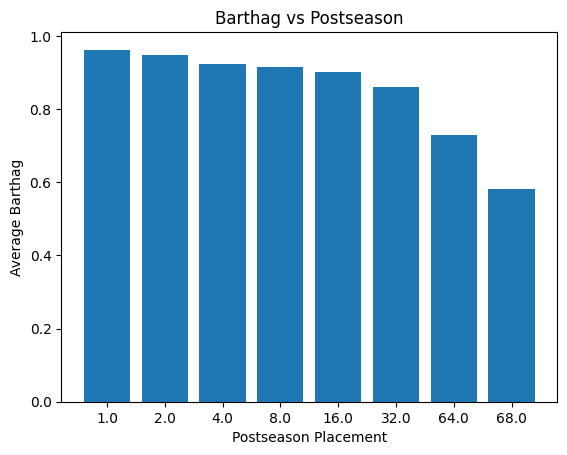

In [24]:
plt.bar(postseason_BARTHAG.index.astype(str),postseason_BARTHAG['BARTHAG']['mean'])
plt.title('Barthag vs Postseason')
plt.ylabel('Average Barthag')
plt.xlabel('Postseason Placement')

Text(0.5, 0, 'Postseason Placement')

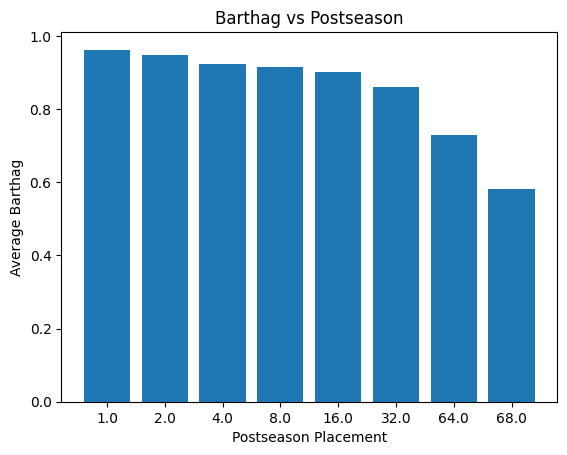

In [25]:
plt.bar(postseason_BARTHAG.index.astype(str),postseason_BARTHAG['BARTHAG']['mean'])
plt.title('Barthag vs Postseason')
plt.ylabel('Average Barthag')
plt.xlabel('Postseason Placement')

Text(0.5, 0, 'Postseason Placement')

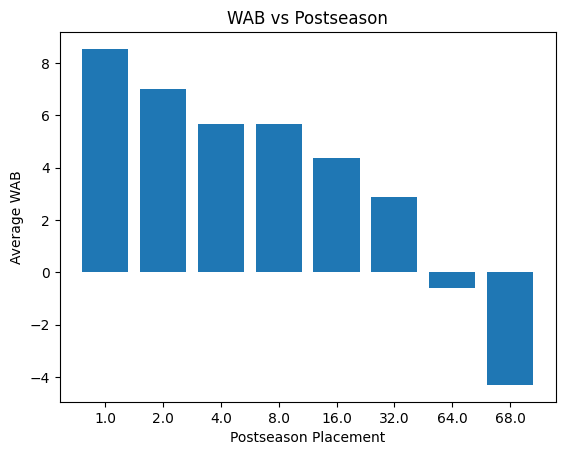

In [26]:
plt.bar(Postseason_WAB.index.astype(str),Postseason_WAB['WAB']['mean'])
plt.title('WAB vs Postseason')
plt.ylabel('Average WAB')
plt.xlabel('Postseason Placement')

# 2.1 Data Cleaning

In [27]:
df.isnull().sum()

TEAM             0
CONF             0
G                0
W                0
ADJOE            0
ADJDE            0
BARTHAG          0
EFG_O            0
EFG_D            0
TOR              0
TORD             0
ORB              0
DRB              0
FTR              0
FTRD             0
2P_O             0
2P_D             0
3P_O             0
3P_D             0
ADJ_T            0
WAB              0
POSTSEASON    2843
SEED          2843
YEAR             0
dtype: int64

In [28]:
df_test = pd.read_csv('/kaggle/input/college-basketball-dataset/cbb.csv')
print(df_test.nunique())

TEAM           368
CONF            35
G               32
W               39
ADJOE          384
ADJDE          331
BARTHAG       2922
EFG_O          187
EFG_D          169
TOR            133
TORD           142
ORB            235
DRB            188
FTR            296
FTRD           334
2P_O           206
2P_D           192
3P_O           165
3P_D           146
ADJ_T          188
WAB            336
POSTSEASON       8
SEED            16
YEAR            10
dtype: int64


In [29]:
print(df_test.shape)

(3523, 24)


In [30]:
counts = df_test.nunique()
to_del = [i for i,v in enumerate(counts) if (float(v)/df.shape[0]*100) < 1]
print(to_del)

[1, 2, 21, 22, 23]


In [31]:
dups = df.duplicated()
print(dups.any())
print(df[dups])

False
Empty DataFrame
Columns: [TEAM, CONF, G, W, ADJOE, ADJDE, BARTHAG, EFG_O, EFG_D, TOR, TORD, ORB, DRB, FTR, FTRD, 2P_O, 2P_D, 3P_O, 3P_D, ADJ_T, WAB, POSTSEASON, SEED, YEAR]
Index: []

[0 rows x 24 columns]


In [32]:
numeric_df.head()

,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,18.2,40.7,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2.0,1.0,2016
1,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,15.8,32.1,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2.0,1.0,2015
2,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,19.5,25.5,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2.0,3.0,2018
3,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,22.8,27.4,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2.0,3.0,2019
4,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,17.1,30.0,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2.0,1.0,2017


In [33]:
from sklearn.feature_selection import VarianceThreshold
data = numeric_df.values
X = data[:, :-1]
y = data[:, -1]
print(X.shape, y.shape)
# define the transform
transform = VarianceThreshold()
# transform the input data
X_sel = transform.fit_transform(X)
print(X_sel.shape)

(3523, 21) (3523,)
(3523, 21)


In [34]:
from numpy import arange
# define thresholds to check
thresholds = arange(0.0, 0.55, 0.05)
# apply transform with each threshold
results = list()
for t in thresholds:
    # define the transform
    transform = VarianceThreshold(threshold=t)
    # transform the input data
    X_sel = transform.fit_transform(X)
    # determine the number of input features
    n_features = X_sel.shape[1]
    print('>Threshold=%.2f, Features=%d' % (t, n_features))
    # store the result
    results.append(n_features)

>Threshold=0.00, Features=21
>Threshold=0.05, Features=21
>Threshold=0.10, Features=20
>Threshold=0.15, Features=20
>Threshold=0.20, Features=20
>Threshold=0.25, Features=20
>Threshold=0.30, Features=20
>Threshold=0.35, Features=20
>Threshold=0.40, Features=20
>Threshold=0.45, Features=20
>Threshold=0.50, Features=20


In [35]:
from numpy import arange

# define thresholds to check
thresholds = arange(0.0, 0.55, 0.05)
# apply transform with each threshold
results = list()

for t in thresholds:
    # define the transform
    transform = VarianceThreshold(threshold=t)
    # fit the transform
    transform.fit(X)
    
    # Get the boolean mask for features retained
    selected_features_mask = transform.get_support()
    
    # Get dropped features
    dropped_features = numeric_df.columns[:-1][~selected_features_mask]  # Exclude the target column
    
    # determine the number of input features
    n_features = sum(selected_features_mask)
    
    print(f'>Threshold={t:.2f}, Features={n_features}, Dropped Features={dropped_features.tolist()}')
    # store the result
    results.append(n_features)


>Threshold=0.00, Features=21, Dropped Features=[]
>Threshold=0.05, Features=21, Dropped Features=[]
>Threshold=0.10, Features=20, Dropped Features=['BARTHAG']
>Threshold=0.15, Features=20, Dropped Features=['BARTHAG']
>Threshold=0.20, Features=20, Dropped Features=['BARTHAG']
>Threshold=0.25, Features=20, Dropped Features=['BARTHAG']
>Threshold=0.30, Features=20, Dropped Features=['BARTHAG']
>Threshold=0.35, Features=20, Dropped Features=['BARTHAG']
>Threshold=0.40, Features=20, Dropped Features=['BARTHAG']
>Threshold=0.45, Features=20, Dropped Features=['BARTHAG']
>Threshold=0.50, Features=20, Dropped Features=['BARTHAG']


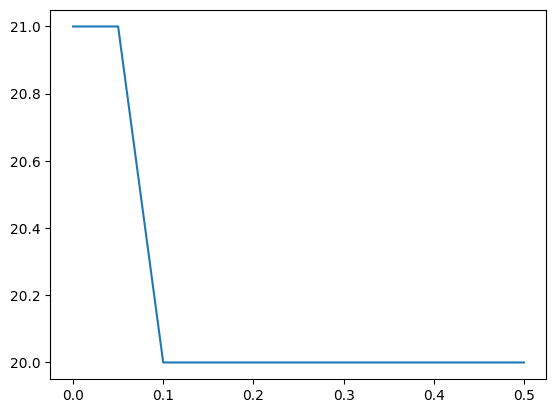

In [36]:
from matplotlib import pyplot
pyplot.plot(thresholds, results)
pyplot.show()

# 3.1 TRAIN-TEST SPLIT

In [37]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

features = ['G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD',
       'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O', '3P_D', 'ADJ_T',
       'WAB','SEED']


df_new = df.dropna(subset=['SEED'] + ['POSTSEASON'])

X = df_new[features]
y = df_new['POSTSEASON']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




# 3.2 SVM Defult parameters

In [38]:
svc = svm.SVC()
svc.fit(X_train_scaled,y_train)
scv_result=svc.predict(X_test_scaled)
print('Accuracy :',accuracy_score(y_test,scv_result))
print(classification_report(y_test,scv_result))

Accuracy : 0.4889705882352941
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         4
         2.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         8
         8.0       0.00      0.00      0.00        16
        16.0       0.30      0.19      0.23        32
        32.0       0.29      0.34      0.32        64
        64.0       0.59      0.82      0.69       128
        68.0       0.00      0.00      0.00        16

    accuracy                           0.49       272
   macro avg       0.15      0.17      0.15       272
weighted avg       0.38      0.49      0.43       272



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


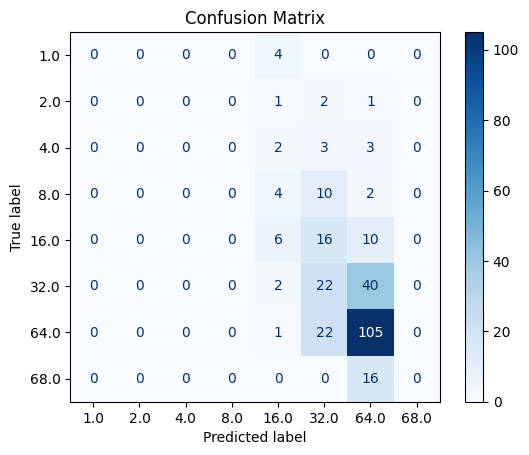

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, scv_result)
classes = np.unique(y_test)  


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()




# 3.2 DecisionTree Defult parameters

In [40]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

dt_result = dt.predict(X_test)


print('Accuracy :', accuracy_score(y_test, dt_result))
print(classification_report(y_test, dt_result))

Accuracy : 0.4411764705882353
              precision    recall  f1-score   support

         1.0       0.14      0.25      0.18         4
         2.0       0.00      0.00      0.00         4
         4.0       0.00      0.00      0.00         8
         8.0       0.21      0.31      0.25        16
        16.0       0.32      0.28      0.30        32
        32.0       0.35      0.34      0.35        64
        64.0       0.61      0.65      0.63       128
        68.0       0.00      0.00      0.00        16

    accuracy                           0.44       272
   macro avg       0.21      0.23      0.21       272
weighted avg       0.42      0.44      0.43       272



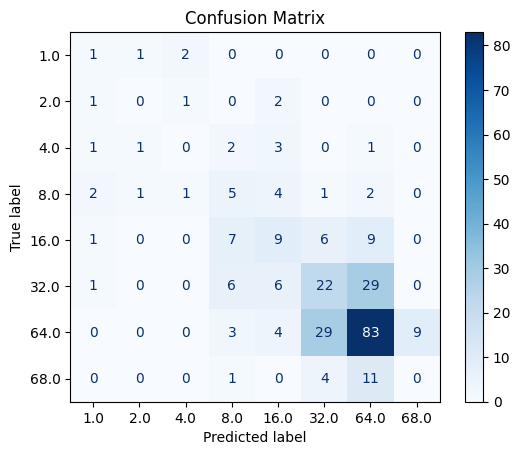

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, dt_result)
classes = np.unique(y_test)  


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()




# 4.1 SVM hyperparameter tuning

In [42]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': ['scale', 'auto']}
grid = GridSearchCV(svm.SVC(class_weight='balanced'), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 100, 'gamma': 'scale'}


In [43]:
svc = svm.SVC(C= 100, gamma= 'scale',class_weight='balanced' )
svc.fit(X_train_scaled,y_train)
scv_result=svc.predict(X_test_scaled)
print('Accuracy :',accuracy_score(y_test,scv_result))
print(classification_report(y_test,scv_result))

Accuracy : 0.4632352941176471
              precision    recall  f1-score   support

         1.0       0.50      0.25      0.33         4
         2.0       0.00      0.00      0.00         4
         4.0       0.29      0.25      0.27         8
         8.0       0.29      0.44      0.35        16
        16.0       0.19      0.25      0.22        32
        32.0       0.29      0.27      0.28        64
        64.0       0.66      0.68      0.67       128
        68.0       0.67      0.25      0.36        16

    accuracy                           0.46       272
   macro avg       0.36      0.30      0.31       272
weighted avg       0.47      0.46      0.46       272



# 4.2 DT hyperparameter tuning

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier


param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'], 
    'max_depth': [None, 10, 20, 30, 50],          
    'min_samples_split': [2, 5, 10],              
    'min_samples_leaf': [1, 2, 5],               
}

grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),  
    param_grid, 
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("best accuracy:", grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
best accuracy: 0.4262872628726287


In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(criterion='gini', max_depth=None, 
                             min_samples_leaf=2, min_samples_split=2,
                            random_state=42)

dt.fit(X_train, y_train)

dt_result = dt.predict(X_test)

print('Accuracy :', accuracy_score(y_test, dt_result))
print(classification_report(y_test, dt_result))


Accuracy : 0.4411764705882353
              precision    recall  f1-score   support

         1.0       0.29      0.50      0.36         4
         2.0       0.20      0.25      0.22         4
         4.0       0.25      0.12      0.17         8
         8.0       0.11      0.12      0.11        16
        16.0       0.21      0.25      0.23        32
        32.0       0.37      0.41      0.39        64
        64.0       0.64      0.60      0.62       128
        68.0       0.43      0.19      0.26        16

    accuracy                           0.44       272
   macro avg       0.31      0.31      0.29       272
weighted avg       0.46      0.44      0.44       272



# 4.3 compering hyperparameters 

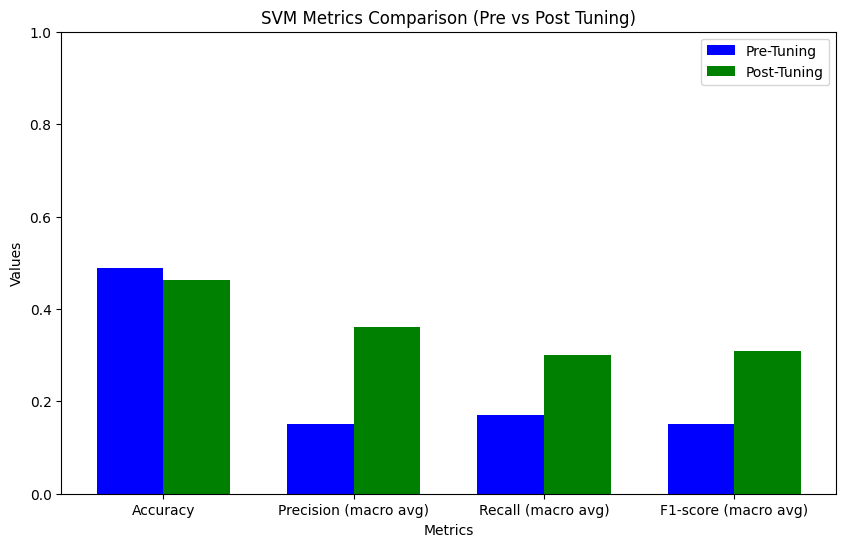

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for SVM pre- and post-tuning
metrics = ['Accuracy', 'Precision (macro avg)', 'Recall (macro avg)', 'F1-score (macro avg)']
svm_pre_metrics = [0.4889705882352941, 0.15, 0.17, 0.15]  # Pre-tuning
svm_post_metrics = [0.4632352941176471, 0.36, 0.30, 0.31]  # Post-tuning

# Bar chart for SVM metrics comparison
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, svm_pre_metrics, width, label='Pre-Tuning', color='blue')
plt.bar(x + width/2, svm_post_metrics, width, label='Post-Tuning', color='green')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('SVM Metrics Comparison (Pre vs Post Tuning)')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.show()


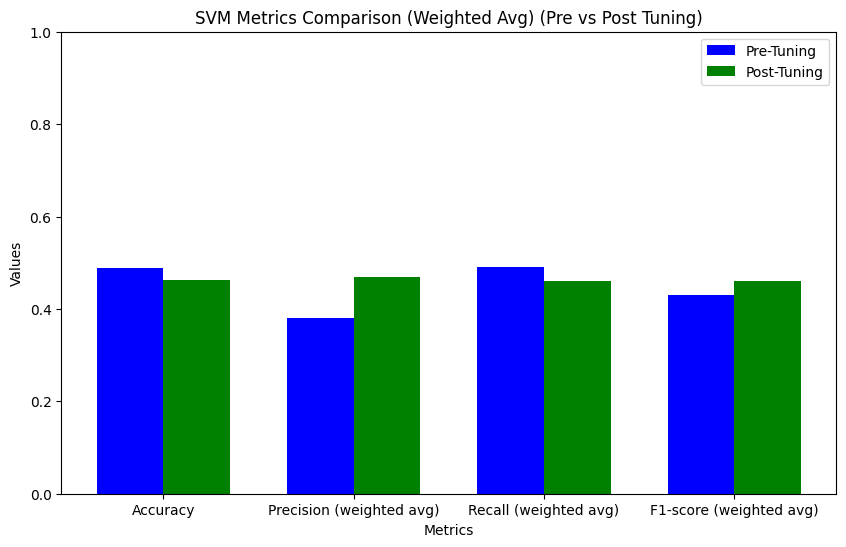

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for SVM pre- and post-tuning (weighted avg)
metrics = ['Accuracy', 'Precision (weighted avg)', 'Recall (weighted avg)', 'F1-score (weighted avg)']
svm_pre_metrics = [0.4889705882352941, 0.38, 0.49, 0.43]  # Pre-tuning
svm_post_metrics = [0.4632352941176471, 0.47, 0.46, 0.46]  # Post-tuning

# Bar chart for SVM metrics comparison (weighted avg)
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, svm_pre_metrics, width, label='Pre-Tuning', color='blue')
plt.bar(x + width/2, svm_post_metrics, width, label='Post-Tuning', color='green')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('SVM Metrics Comparison (Weighted Avg) (Pre vs Post Tuning)')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.show()


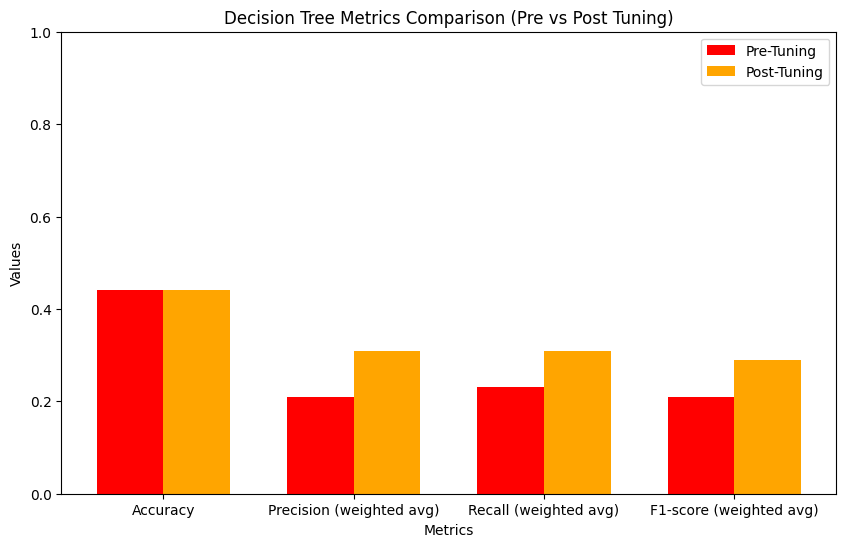

In [48]:
# Metrics for Decision Tree pre- and post-tuning
dt_pre_metrics = [0.4411764705882353, 0.21, 0.23, 0.21 ]  # Pre-tuning
dt_post_metrics = [0.4411764705882353, 0.31, 0.31, 0.29]  # Post-tuning

# Bar chart for Decision Tree metrics comparison
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, dt_pre_metrics, width, label='Pre-Tuning', color='red')
plt.bar(x + width/2, dt_post_metrics, width, label='Post-Tuning', color='orange')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Decision Tree Metrics Comparison (Pre vs Post Tuning)')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.show()


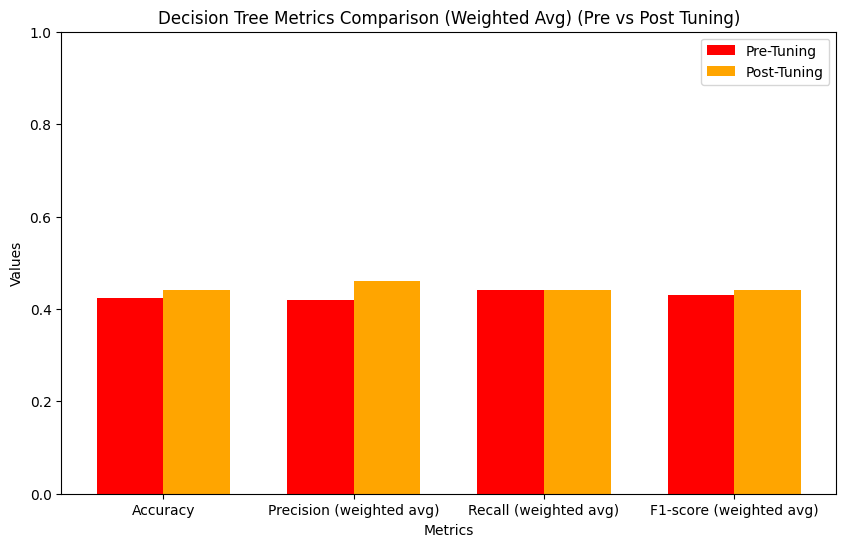

In [49]:
# Metrics for Decision Tree pre- and post-tuning (weighted avg)
dt_pre_metrics = [0.4227941176470588,  0.42, 0.44, 0.43]  # Pre-tuning
dt_post_metrics = [0.4411764705882353, 0.46, 0.44, 0.44]  # Post-tuning

# Bar chart for Decision Tree metrics comparison (weighted avg)
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, dt_pre_metrics, width, label='Pre-Tuning', color='red')
plt.bar(x + width/2, dt_post_metrics, width, label='Post-Tuning', color='orange')

plt.xlabel('Metrics')
plt.ylabel('Values')
plt.title('Decision Tree Metrics Comparison (Weighted Avg) (Pre vs Post Tuning)')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.show()


# **------Neural Network-----**

In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [51]:
#VARIABLES
test_data_portion = 0.2
seed = 8

hidden_layer_nodes = 20
learning_rate = 0.01
epochs = 1000

report_loss_every = epochs/10

In [52]:
#Model class inheriting nn.Module
class Model(nn.Module):
    #Input layer (20 basketball features)
    #Hidden layer 1
    #Hidden layer 2
    #Output (8 classes of postseason)
    def __init__(self, in_features=20, h1=hidden_layer_nodes,h2=hidden_layer_nodes,h3=hidden_layer_nodes, out_features=8):
        super().__init__() #instantiate nn.module
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1,h2)
        # self.fc3 = nn.Linear(h2,h3)
        self.out = nn.Linear(h2,out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # x = F.relu(self.fc3(x))
        x = F.relu(self.out(x))

        return x



In [53]:
#Pick a manual seed for randomization
torch.manual_seed(seed)

#instance of model
model = Model()

### Load Data

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib inline

In [55]:
#import data
data = pd.read_csv('/kaggle/input/college-basketball-dataset/cbb.csv')
data['POSTSEASON'].value_counts()

#Clean the data
postseason_mapping = {'Champions':0,
                     '2ND':1,
                     'F4':2,
                     'E8':3,
                     'S16':4,
                     'R32':5,
                     'R64':6,
                     'R68':7}
data['POSTSEASON'] = data['POSTSEASON'].map(postseason_mapping)
data = data.dropna() #remove NaN values in postseason and seed features
data = data._get_numeric_data() #remove team names and conference names
data = data.drop('YEAR', axis=1) #year is irrelevant to our processing


### Model data prep

In [56]:
#split into X/y
X = data.drop('POSTSEASON',axis=1)
y = data['POSTSEASON']
X = X.values #turns df into numpy array
y = y.values


In [57]:
#split into train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=test_data_portion, random_state = seed)

# y_train = y_train.reshape(-1,1)
# y_test = y_test.reshape(-1,1)

In [58]:
#scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# y_train = scaler.fit_transform(y_train)
# y_test = scaler.transform(y_test)

In [59]:

#convert to tensor variables
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [60]:
#set criterion to calculate error
criterion = nn.CrossEntropyLoss()
#choose optimizer (how it learns): Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

### Train model

Epoch: 0 and loss: 2.0998668670654297
Epoch: 100 and loss: 0.8787912726402283
Epoch: 200 and loss: 0.36106324195861816
Epoch: 300 and loss: 0.183848038315773
Epoch: 400 and loss: 0.14538058638572693
Epoch: 500 and loss: 0.13412128388881683
Epoch: 600 and loss: 0.1298929750919342
Epoch: 700 and loss: 0.12831895053386688
Epoch: 800 and loss: 0.12754389643669128
Epoch: 900 and loss: 0.12713098526000977


<function matplotlib.pyplot.show(close=None, block=None)>

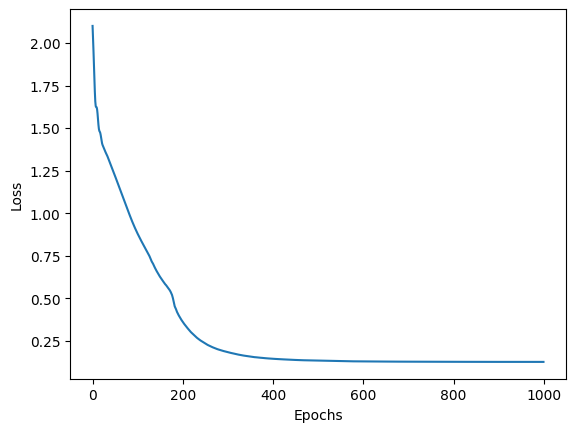

In [61]:
#Train the model
losses = []
for i in range(epochs):
    #go forward and get prediction
    y_pred = model.forward(X_train) # get predicted results

    #measure the loss
    loss = criterion(y_pred, y_train)
    losses.append(loss.detach().numpy())

    #print every 10 epochs
    if i%report_loss_every==0:
        print(f'Epoch: {i} and loss: {loss}')

    #backpropogation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

#graph
plt.plot(range(epochs),losses)
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show

In [62]:
#graph
# plt.plot(range(epochs),losses)
# plt.ylabel("Loss")
# plt.xlabel("Epochs")
# plt.show

In [63]:
#Evaluate model
with torch.no_grad(): #turn off back propogation
    y_eval = model.forward(X_test) #y_eval will be predictions
    loss = criterion(y_eval, y_test)

loss

tensor(9.4745)

In [64]:
correct = 0
total = 0
y_results = []
with torch.no_grad(): #turn off back propogation
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        #will tell us what ou
        # print(f'{i+1}) {str(y_val)} \t {y_test[i]}')

        total += 1
        y_results.append(y_val.argmax().item())
        if y_val.argmax().item() == y_test[i]:
            correct += 1

print(f'We got {correct} of {total} correct')
accuracy = correct/total
print(f'Accuracy: {accuracy}')

We got 67 of 136 correct
Accuracy: 0.49264705882352944


In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test,y_results))
# y_test
# y_results

              precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         2
           3       0.50      0.23      0.32        13
           4       0.10      0.18      0.12        11
           5       0.37      0.26      0.31        38
           6       0.64      0.79      0.71        62
           7       0.67      0.50      0.57         4

    accuracy                           0.49       136
   macro avg       0.33      0.29      0.30       136
weighted avg       0.48      0.49      0.47       136



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


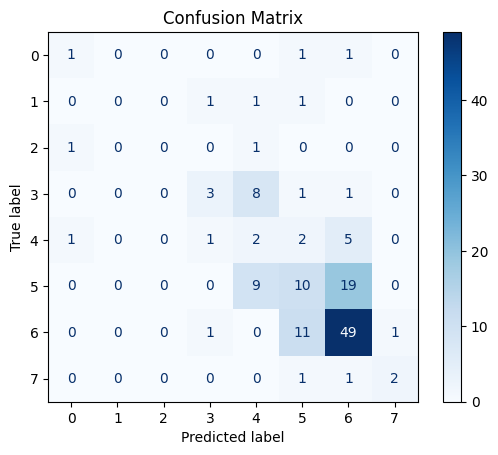

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, y_results)
classes = np.unique(y_test)  


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
